In [1]:
import numpy as np
import pandas as pd
import torch


In [ ]:
a = torch.tensor(1)  # 0d
a

In [ ]:
b = torch.tensor([1, 2, 3])  # 1d
b

In [ ]:
c = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 2d
c

In [ ]:
arr = np.array([1, 2, 3])
arr

In [ ]:
arr_tensor = torch.from_numpy(arr)
arr_tensor

In [ ]:
arr[0] = 5

In [ ]:
arr_tensor

# PyTorch. Tensor

## Device

* 'cpu' - процесор
* 'cuda' - Nvidia відеокарта
* 'mps' - Apple M1, M2, M3

# requires_gard

Автоматичний підрахунок градієнтів

In [ ]:
w = torch.tensor(2, dtype=torch.float32, device='cpu', requires_grad=True) 

In [ ]:
b = torch.tensor(3)

c = w**2
c = c + b

c

In [ ]:
X = torch.arange(1, 201)  # числа від 1 до 200
X = torch.randn(200)   # нормально розподілені числа з середнім=0, стандартне відхилення: 1.5

In [ ]:
c.backward()


In [ ]:
a.grad

In [2]:
from torch import nn

loss_fn = nn.MSELoss()

In [55]:
X = torch.normal(22, 2, size=(200, )).reshape(-1, 1)  # середнє 22, стардатне відхилення 2
display(X.shape)

y = 2.0 * X + 3 + 0.1 * torch.randn(200, 1)
display(y.shape)

# параметр швидкості навчання
learning_rate = 0.0001

history = []

# створюємо модель
model = nn.Linear(1, 1)

for epoch in range(1001):
    # один крок тренування (пропускаємо X через модель)
    # рух вперед (forward)
    y_pred = model(X)
    
    # рахуємо помилку
    loss = loss_fn(y_pred, y)
    
    # рух назад
    loss.backward()
    
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad
    
    # обнулити градієнти
    model.zero_grad()
    
    history.append({
        "epoch": epoch,
        "loss": loss.item(),
        "weight": model.weight.item(),
        "bias": model.bias.item()
    })

history_df = pd.DataFrame(history)
history_df.head(10)

torch.Size([200, 1])

torch.Size([200, 1])

,epoch,loss,weight,bias
0,0,2710.758057,0.027410,0.098792
1,1,2197.387451,0.236478,0.108140
2,2,1781.242310,0.424711,0.116557
3,3,1443.909424,0.594185,0.124136
4,4,1170.462769,0.746768,0.130959
5,5,948.803467,0.884146,0.137103
6,6,769.123352,1.007832,0.142635
7,7,623.472412,1.119192,0.147617
8,8,505.405701,1.219454,0.152102
9,9,409.699341,1.309724,0.156140


In [56]:
history_df.tail(10)

,epoch,loss,weight,bias
991,991,0.056376,2.125084,0.196044
992,992,0.056376,2.125084,0.196048
993,993,0.056376,2.125084,0.196051
994,994,0.056376,2.125084,0.196055
995,995,0.056376,2.125084,0.196058
996,996,0.056376,2.125084,0.196062
997,997,0.056376,2.125084,0.196066
998,998,0.056376,2.125083,0.196069
999,999,0.056375,2.125083,0.196073
1000,1000,0.056375,2.125083,0.196076


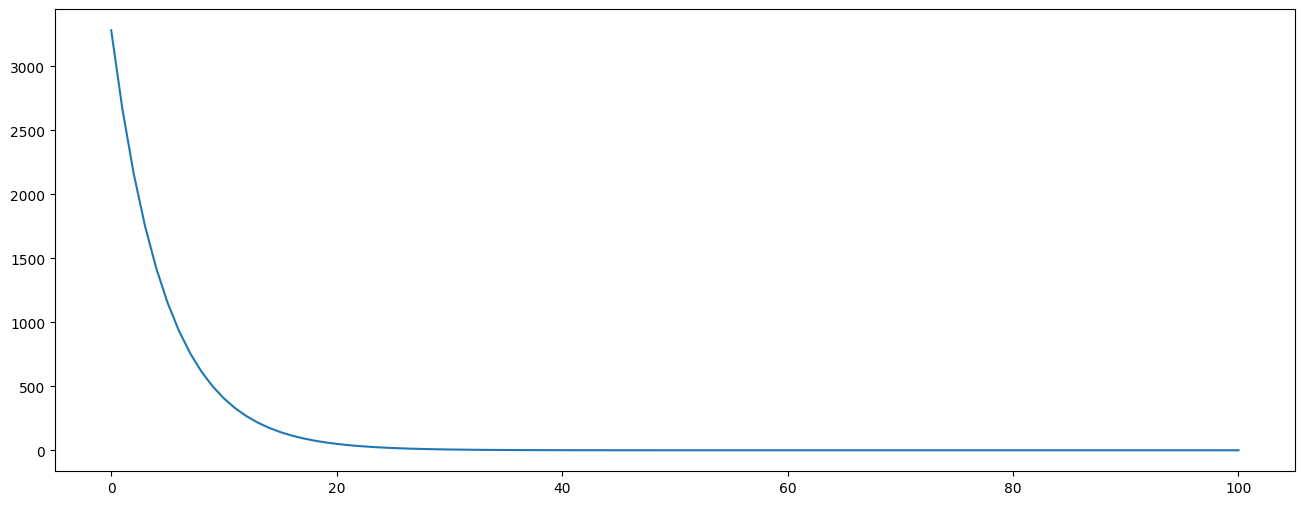

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(history_df.index, history_df['loss'])

plt.show()